EMPLOYEE PROMOTION PREDICTION DATASET


,performance,experience,training,attendance,promotion
0,Excellent,High,Completed,High,1
1,Good,Medium,Completed,High,1
2,Average,Low,Incomplete,Medium,0
3,Excellent,High,Completed,High,1
4,Poor,Low,Incomplete,Low,0
5,Good,Medium,Completed,Medium,1
6,Excellent,High,Completed,High,1
7,Average,Low,Incomplete,Medium,0
8,Good,Medium,Completed,High,1
9,Excellent,High,Completed,High,1



Dataset Shape:
(20, 5)

Missing Values:
performance    0
experience     0
training       0
attendance     0
promotion      0
dtype: int64

Features:
['performance', 'experience', 'training', 'attendance']

Target:
promotion

Training Samples: 16
Testing Samples : 4

Model trained successfully!

Actual Values:
[1 0 1 1]

Predicted Values:
[1 0 1 1]

MODEL PERFORMANCE
Accuracy  : 1.00
Precision : 1.00
Recall    : 1.00
F1-Score  : 1.00

Confusion Matrix:
[[1 0]
 [0 3]]


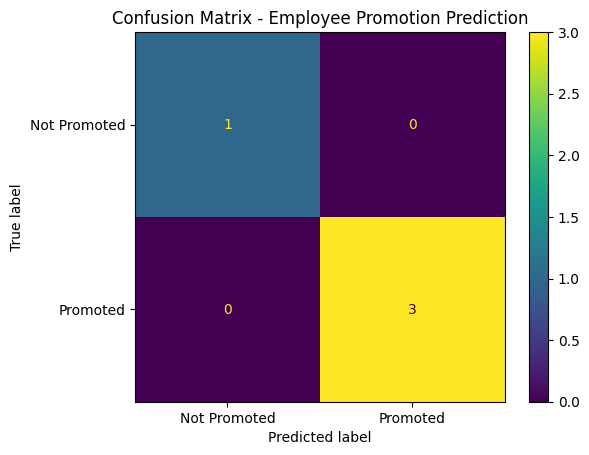

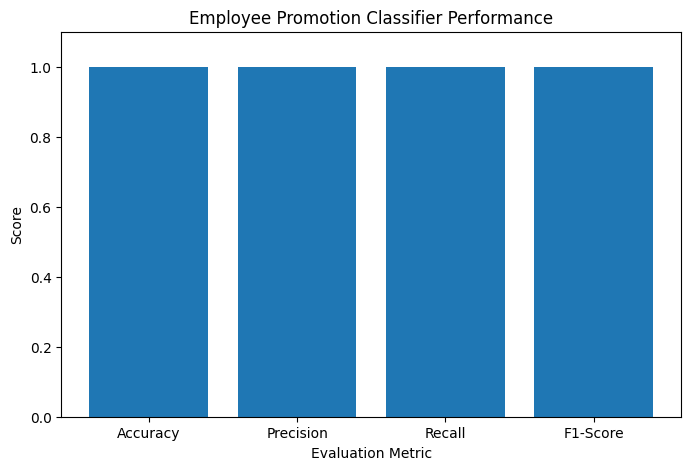

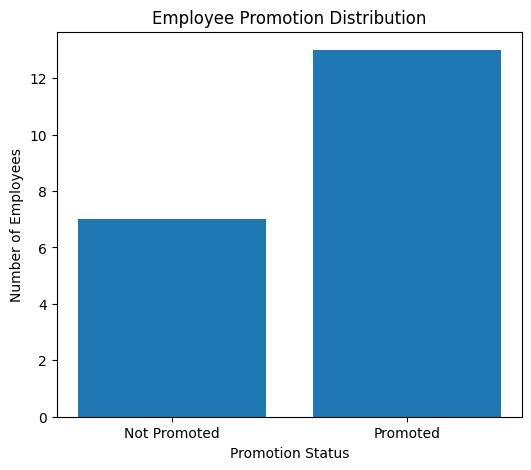

In [1]:
# ============================================================
# PROGRAM 2: BASIC SUPERVISED LEARNING PIPELINE
# Dataset: Employee Promotion Prediction
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    "performance": [
        "Excellent", "Good", "Average", "Excellent", "Poor",
        "Good", "Excellent", "Average", "Good", "Excellent",
        "Poor", "Good", "Excellent", "Average", "Good",
        "Excellent", "Poor", "Good", "Excellent", "Average"
    ],

    "experience": [
        "High", "Medium", "Low", "High", "Low",
        "Medium", "High", "Low", "Medium", "High",
        "Low", "Medium", "High", "Low", "Medium",
        "High", "Low", "Medium", "High", "Low"
    ],

    "training": [
        "Completed", "Completed", "Incomplete", "Completed", "Incomplete",
        "Completed", "Completed", "Incomplete", "Completed", "Completed",
        "Incomplete", "Completed", "Completed", "Incomplete", "Completed",
        "Completed", "Incomplete", "Completed", "Completed", "Incomplete"
    ],

    "attendance": [
        "High", "High", "Medium", "High", "Low",
        "Medium", "High", "Medium", "High", "High",
        "Low", "Medium", "High", "Low", "High",
        "High", "Low", "Medium", "High", "Medium"
    ],

    "promotion": [
        1, 1, 0, 1, 0,
        1, 1, 0, 1, 1,
        0, 1, 1, 0, 1,
        1, 0, 1, 1, 0
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 2. DISPLAY DATASET
# ============================================================

print("EMPLOYEE PROMOTION PREDICTION DATASET")
print("=" * 60)

display(df.head(10))

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 3. CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. ENCODE CATEGORICAL FEATURES
# ============================================================

# Convert categorical columns into numerical values

df["performance"] = df["performance"].map({
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
})

df["experience"] = df["experience"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

df["training"] = df["training"].map({
    "Incomplete": 0,
    "Completed": 1
})

df["attendance"] = df["attendance"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

# promotion is the target column

X = df[
    [
        "performance",
        "experience",
        "training",
        "attendance"
    ]
]

y = df["promotion"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("promotion")


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 7. CREATE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# ============================================================
# 8. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# 10. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ============================================================
# 11. DISPLAY PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 13. PLOT CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Promoted", "Promoted"]
)

disp.plot()

plt.title("Confusion Matrix - Employee Promotion Prediction")

plt.show()


# ============================================================
# 14. GRAPH - PERFORMANCE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.ylim(0, 1.1)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title("Employee Promotion Classifier Performance")

plt.show()


# ============================================================
# 15. GRAPH - PROMOTION DISTRIBUTION
# ============================================================

promotion_count = df["promotion"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ["Not Promoted", "Promoted"],
    [
        promotion_count.get(0, 0),
        promotion_count.get(1, 0)
    ]
)

plt.xlabel("Promotion Status")
plt.ylabel("Number of Employees")

plt.title("Employee Promotion Distribution")

plt.show()